In [1]:
# curl -LsSf https://astral.sh/uv/install.sh | sh
# source $HOME/.local/bin/env

In [2]:
# uv venv mlprague_venv --python 3.12

In [3]:
# uv pip install ipykernel

In [4]:
# !~/.local/bin/uv pip install transformers datasets matplotlib seaborn scikit-learn beautifulsoup4 trl pandas ipykernel ipywidgets wandb packaging setuptools torch==2.8 liger-kernel peft --python mlprague_venv/bin/python
# !~/.local/bin/uv pip install flash-attn --no-build-isolation --python mlprague_venv/bin/python

In [2]:
GPU_DEVICES = [0]

import os
os.environ['HF_HUB_DISABLE_XET'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'true'
os.environ["CUDA_VISIBLE_DEVICES"] = ",".join([str(i) for i in GPU_DEVICES])

In [3]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    set_seed,
)
from trl import SFTTrainer, SFTConfig, get_peft_config
from peft import LoraConfig
from datasets import load_dataset



def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

    # Makes CUDA deterministic (optional)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_all_seeds(42)

In [4]:
from datasets import load_dataset, Dataset

N_SAMPLES = 10000

stream = load_dataset("phreshphish/phreshphish", split="train", streaming=True)
sampled = Dataset.from_list(list(stream.take(N_SAMPLES)))
print(f"Sampled {len(sampled)} examples")
print(sampled[0])

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Sampled 10000 examples
{'sha256': 'e5bf57080abb02f77b6f1767a26c19f2ea026d1d553cb8c44b61344ce248a3a3', 'url': 'https://www.lifeonthemediterranean.com/portofino-italy-worth-a-visit/', 'label': 'benign', 'target': None, 'date': datetime.date(2025, 8, 3), 'lang': 'en', 'lang_score': 0.9433812499046326, 'html': '<html lang="en-US"><head><meta charset="UTF-8"><meta name="viewport" content="width=device-width, initial-scale=1"><link rel="profile" href="https://gmpg.org/xfn/11"> <!-- [BEGIN] Metadata added via All-Meta-Tags plugin by Space X-Chimp ( https://www.spacexchimp.com ) --><meta name="p:domain_verify" content="https://www.pinterest.fr/lifeonthemediterranean/"><link rel="author" href="https://plus.google.com/+LifeOnTheMediterranean"><meta name="article:publisher" content="https://www.facebook.com/LifeOnTheMed/"><meta name="twitter:site" content="@LifeOnTheMedSea"><meta name="twitter:creator" content="@LifeOnTheMedSea"><meta name="author" content="Maureen McDermott"><meta name="designer

In [5]:
from datasets import concatenate_datasets
import pandas as pd

print(f"=== Raw sampled dataset ===")
print(f"Total samples: {len(sampled)}")
print(f"Columns: {sampled.column_names}")
lang_counts = pd.Series(sampled['lang']).value_counts()
english_count = lang_counts.get('en', 0)
print(f"English: {english_count} ({english_count/len(sampled)*100:.1f}%) | Other languages: {len(sampled) - english_count}")
print(f"Top 10 languages:\n{lang_counts.head(10).to_string()}")
print(f"Labels: {pd.Series(sampled['label']).value_counts().to_string()}")
print()

dataset = sampled.filter(lambda x: x["lang"] == "en")
non_english_count = len(sampled) - len(dataset)
print(f"=== After language filter ===")
print(f"Kept: {len(dataset)} English | Removed: {non_english_count} non-English ({non_english_count/len(sampled)*100:.1f}%)")
print(f"Labels: {pd.Series(dataset['label']).value_counts().to_string()}")

=== Raw sampled dataset ===
Total samples: 10000
Columns: ['sha256', 'url', 'label', 'target', 'date', 'lang', 'lang_score', 'html']
English: 8350 (83.5%) | Other languages: 1650
Top 10 languages:
en    8350
ja     654
fr     157
it     102
es      94
de      91
pt      67
ru      36
nl      30
pl      27
Labels: benign    5525
phish     4475



Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

=== After language filter ===
Kept: 8350 English | Removed: 1650 non-English (16.5%)
Labels: benign    4915
phish     3435


In [6]:
drop_cols = ["sha256", "target", "date", "lang", "lang_score"]
dataset = dataset.remove_columns(drop_cols)
print(f"Removed columns: {drop_cols}")
print(f"Remaining columns: {dataset.column_names}")
print(f"Total samples: {len(dataset)}")

Removed columns: ['sha256', 'target', 'date', 'lang', 'lang_score']
Remaining columns: ['url', 'label', 'html']
Total samples: 8350


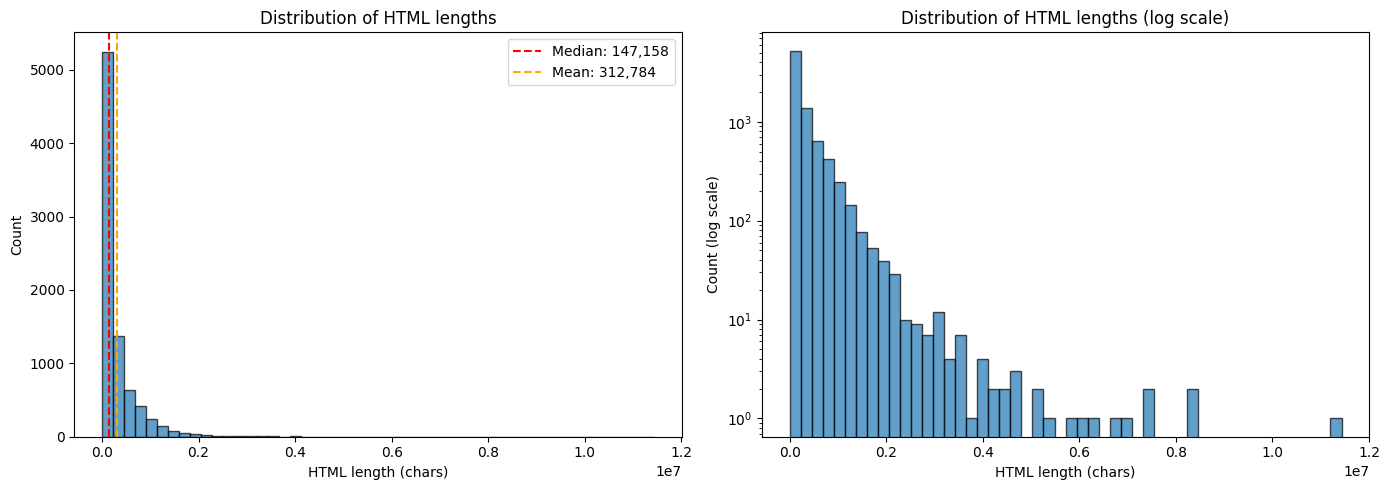

Min: 62 | Max: 11,431,117 | Median: 147,158 | Mean: 312,784


In [7]:
import matplotlib.pyplot as plt
import numpy as np

html_lengths = [len(x) for x in dataset["html"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(html_lengths, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("HTML length (chars)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of HTML lengths")
axes[0].axvline(np.median(html_lengths), color="red", linestyle="--", label=f"Median: {np.median(html_lengths):,.0f}")
axes[0].axvline(np.mean(html_lengths), color="orange", linestyle="--", label=f"Mean: {np.mean(html_lengths):,.0f}")
axes[0].legend()

axes[1].hist(html_lengths, bins=50, edgecolor="black", alpha=0.7, log=True)
axes[1].set_xlabel("HTML length (chars)")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_title("Distribution of HTML lengths (log scale)")

plt.tight_layout()
plt.show()

print(f"Min: {min(html_lengths):,} | Max: {max(html_lengths):,} | Median: {np.median(html_lengths):,.0f} | Mean: {np.mean(html_lengths):,.0f}")

In [ ]:
from bs4 import BeautifulSoup
import re

KEEP_TAGS = {"title", "meta", "form", "input", "button", "select", "textarea", "a", "img", "iframe", "label", "h1", "h2", "h3"}
KEEP_ATTRS = {"href", "src", "action", "method", "type", "name", "placeholder", "alt", "content", "value", "target"}

def clean_html(raw_html):
    soup = BeautifulSoup(raw_html, "html.parser")

    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()
    from bs4 import Comment
    for comment in soup.find_all(string=lambda t: isinstance(t, Comment)):
        comment.extract()

    kept_parts = []
    for tag in soup.find_all(KEEP_TAGS):
        filtered_attrs = {k: v for k, v in tag.attrs.items() if k in KEEP_ATTRS}
        tag.attrs = filtered_attrs
        for child in tag.find_all(True):
            child_attrs = {k: v for k, v in child.attrs.items() if k in KEEP_ATTRS}
            child.attrs = child_attrs
        kept_parts.append(str(tag))

    return "\n".join(kept_parts)

original_lengths = [len(x) for x in dataset["html"]]
dataset = dataset.map(lambda x: {"html": clean_html(x["html"])})
cleaned_lengths = [len(x) for x in dataset["html"]]

print(f"=== HTML Cleaning Results ===")
print(f"Avg length before: {np.mean(original_lengths):,.0f} chars")
print(f"Avg length after:  {np.mean(cleaned_lengths):,.0f} chars")
print(f"Avg reduction:     {(1 - np.mean(cleaned_lengths)/np.mean(original_lengths))*100:.1f}%")
print(f"\nSample cleaned HTML (first 500 chars):")
print(dataset["html"][0][:500])

Map:   0%|          | 0/8350 [00:00<?, ? examples/s]

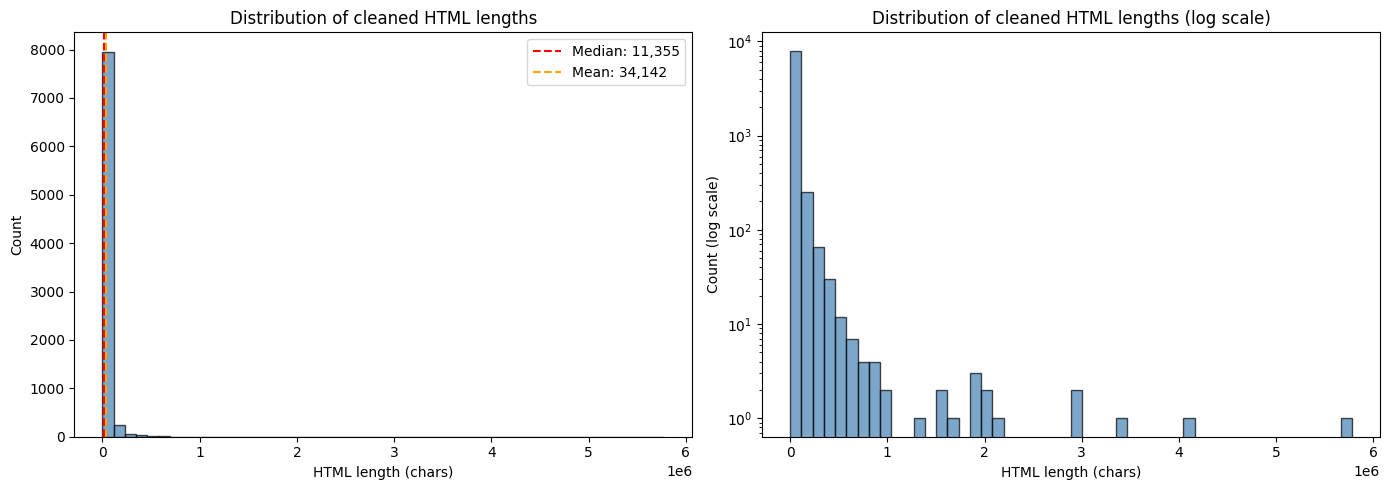

Min: 0 | Max: 5,779,524 | Median: 11,355 | Mean: 34,142


In [ ]:
html_lengths_clean = [len(x) for x in dataset["html"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(html_lengths_clean, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_xlabel("HTML length (chars)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of cleaned HTML lengths")
axes[0].axvline(np.median(html_lengths_clean), color="red", linestyle="--", label=f"Median: {np.median(html_lengths_clean):,.0f}")
axes[0].axvline(np.mean(html_lengths_clean), color="orange", linestyle="--", label=f"Mean: {np.mean(html_lengths_clean):,.0f}")
axes[0].legend()

axes[1].hist(html_lengths_clean, bins=50, edgecolor="black", alpha=0.7, color="steelblue", log=True)
axes[1].set_xlabel("HTML length (chars)")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_title("Distribution of cleaned HTML lengths (log scale)")

plt.tight_layout()
plt.show()

print(f"Min: {min(html_lengths_clean):,} | Max: {max(html_lengths_clean):,} | Median: {np.median(html_lengths_clean):,.0f} | Mean: {np.mean(html_lengths_clean):,.0f}")

In [13]:
MAX_HTML_LEN = 20_000

before_count = len(dataset)
dataset = dataset.filter(lambda x: len(x["html"]) <= MAX_HTML_LEN)
print(f"=== HTML length filter ===")
print(f"Filtered HTML > {MAX_HTML_LEN:,} chars: {before_count} → {len(dataset)} samples (removed {before_count - len(dataset)})")
print(f"Labels: {pd.Series(dataset['label']).value_counts().to_string()}")
print()

benign = dataset.filter(lambda x: x["label"] == "benign")
phish = dataset.filter(lambda x: x["label"] == "phish")
min_count = min(len(benign), len(phish))

print(f"=== Balancing ===")
print(f"Before: benign={len(benign)}, phish={len(phish)}")
print(f"Downsampling to {min_count} per class")

benign = benign.shuffle(seed=42).select(range(min_count))
phish = phish.shuffle(seed=42).select(range(min_count))
balanced = concatenate_datasets([benign, phish]).shuffle(seed=42)

print()
print(f"=== Final balanced dataset ===")
print(f"Total: {len(balanced)} samples")
print(f"Labels: {pd.Series(balanced['label']).value_counts().to_string()}")

Filter:   0%|          | 0/8350 [00:00<?, ? examples/s]

=== HTML length filter ===
Filtered HTML > 20,000 chars: 8350 → 5063 samples (removed 3287)
Labels: phish     3120
benign    1943



Filter:   0%|          | 0/5063 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5063 [00:00<?, ? examples/s]

=== Balancing ===
Before: benign=1943, phish=3120
Downsampling to 1943 per class

=== Final balanced dataset ===
Total: 3886 samples
Labels: benign    1943
phish     1943


In [14]:
train_test = balanced.train_test_split(test_size=0.2, seed=42)
train_ds = train_test["train"]
test_val = train_test["test"].train_test_split(test_size=0.5, seed=42)
val_ds = test_val["train"]
test_ds = test_val["test"]

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
for name, ds in [("Train", train_ds), ("Val", val_ds), ("Test", test_ds)]:
    counts = pd.Series(ds["label"]).value_counts()
    print(f"  {name}: {counts.to_dict()}")

Train: 3108 | Val: 389 | Test: 389
  Train: {'benign': 1570, 'phish': 1538}
  Val: {'phish': 202, 'benign': 187}
  Test: {'phish': 203, 'benign': 186}


In [15]:
# Load Tokenizer and Model
model_id = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id, attn_implementation="sdpa", torch_dtype=torch.bfloat16,
).to("cuda")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [16]:
prompt_template = """Analyze the following webpage and determine if it is a phishing page or a benign (legitimate) page.

URL: {url}

HTML content:
{html}

Classify this webpage as either "phish" or "benign". Output your prediction in XML format: <prediction>phish</prediction> or <prediction>benign</prediction>"""

def preprocess_function(examples):
    urls = examples["url"]
    htmls = examples["html"]
    labels = examples["label"]

    prompts = [prompt_template.format(url=url, html=html) for url, html in zip(urls, htmls)]

    messages = [
        [
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": f"<prediction>{label}</prediction>"},
        ]
        for prompt, label in zip(prompts, labels)
    ]

    return {"messages": messages}


In [17]:
train_ds = train_ds.map(preprocess_function, batched=True)
val_ds = val_ds.map(preprocess_function, batched=True)
test_ds = test_ds.map(preprocess_function, batched=True)

print("Sample message:")
for msg in train_ds[0]["messages"]:
    content_preview = msg["content"][:300] + "..." if len(msg["content"]) > 300 else msg["content"]
    print(f"  [{msg['role']}]: {content_preview}")

Map:   0%|          | 0/3108 [00:00<?, ? examples/s]

Map:   0%|          | 0/389 [00:00<?, ? examples/s]

Map:   0%|          | 0/389 [00:00<?, ? examples/s]

Sample message:
  [user]: Analyze the following webpage and determine if it is a phishing page or a benign (legitimate) page.

URL: https://www.britannica.com/money/Peter-Thiel

HTML content:
<meta/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<title>Peter Thiel | Biography &amp; Facts | Britannica ...
  [assistant]: <prediction>benign</prediction>


In [18]:
train_ds[0]

{'url': 'https://www.britannica.com/money/Peter-Thiel',
 'label': 'benign',
 'html': '<meta/>\n<meta content="width=device-width, initial-scale=1" name="viewport"/>\n<title>Peter Thiel | Biography &amp; Facts | Britannica Money</title>\n<meta content="Peter Thiel, German American entrepreneur and business executive who helped found PayPal and Palantir Technologies." name="description"/>\n<meta content="Britannica Money"/>\n<meta content="Peter Thiel, German American entrepreneur and business executive who helped found PayPal and Palantir Technologies."/>\n<meta content="image/png"/>\n<meta content="595"/>\n<meta content="596"/>\n<meta content="Britannica thistle\n"/>\n<meta content="https://www.britannica.com/money/money/opengraph-image.png?0ca1ca22e32fe0d6"/>\n<meta content="summary_large_image" name="twitter:card"/>\n<meta content="Britannica Money" name="twitter:title"/>\n<meta content="Peter Thiel, German American entrepreneur and business executive who helped found PayPal and Pala

In [20]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(model, tokenizer, eval_ds, batch_size=16, max_new_tokens=1024):
    model.eval()
    responses = []
    labels = []
    tokenizer.padding_side = "left"

    for start_idx in tqdm(range(0, len(eval_ds), batch_size)):
        end_idx = min(start_idx + batch_size, len(eval_ds))

        batch_messages = [eval_ds[i]["messages"][:1] for i in range(start_idx, end_idx)]
        batch_labels = [eval_ds[i]["label"] for i in range(start_idx, end_idx)]

        texts = [
            tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
            for messages in batch_messages
        ]

        model_inputs = tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
        ).to(model.device)

        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.0,
            do_sample=False,
        )

        generated_ids = [
            output_ids[len(input_ids):]
            for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
        ]

        batch_responses = tokenizer.batch_decode(
            generated_ids,
            skip_special_tokens=True,
        )

        responses.extend(batch_responses)
        labels.extend(batch_labels)

    import re
    def parse_prediction(response):
        match = re.search(r"<prediction>(.*?)</prediction>", response)
        return match.group(1).strip().lower() if match else response.strip().lower()

    parsed = [parse_prediction(r) for r in responses]
    acc = accuracy_score(labels, parsed)
    valid_labels = [l for l, p in zip(labels, parsed) if p in ("phish", "benign")]
    valid_responses = [p for p in parsed if p in ("phish", "benign")]
    invalid_count = len(parsed) - len(valid_responses)

    print(f"Accuracy:  {100 * acc:.2f}%")
    if valid_responses:
        print(f"Precision: {100 * precision_score(valid_labels, valid_responses, pos_label='phish'):.2f}%")
        print(f"Recall:    {100 * recall_score(valid_labels, valid_responses, pos_label='phish'):.2f}%")
        print(f"F1:        {100 * f1_score(valid_labels, valid_responses, pos_label='phish'):.2f}%")
        print(f"\nConfusion matrix (rows=true, cols=pred):")
        cm = confusion_matrix(valid_labels, valid_responses, labels=["benign", "phish"])
        print(pd.DataFrame(cm, index=["true_benign", "true_phish"], columns=["pred_benign", "pred_phish"]))
    if invalid_count > 0:
        print(f"\nInvalid responses: {invalid_count}/{len(responses)}")
        print(f"Examples: {[r for r, p in zip(responses, parsed) if p not in ('phish', 'benign')][:5]}")

    return {
        "responses": responses,
        "parsed": parsed,
        "labels": labels,
        "accuracy": acc,
    }

results = evaluate_model(model, tokenizer, train_ds)

100%|██████████| 195/195 [07:35<00:00,  2.34s/it]


Accuracy:  46.33%
Precision: 66.67%
Recall:    0.27%
F1:        0.53%

Confusion matrix (rows=true, cols=pred):
             pred_benign  pred_phish
true_benign         1436           2
true_phish          1498           4

Invalid responses: 168/3108
Examples: ['<prediction>benevolent</prediction>', '```xml\n<prediction>benevolent</prediction>\n```', '```xml\n<prediction>benevolent</prediction>\n```', '```xml\n<prediction>benevolent</prediction>\n```', '```xml\n<prediction>benevolent</prediction>\n```']


In [1]:
extra_kwargs = {
    "optim": "adamw_torch_fused",
    "learning_rate": 3e-04,
    "lr_scheduler_type": "constant_with_warmup",
    "max_grad_norm": 0.2,
    "warmup_steps": 5,
    "weight_decay": 0.1,

    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 16,
    "max_steps": 100
}

peft_config = None # or peft_config = LoraConfig(???)



training_args = SFTConfig(
    output_dir="./results",    
    eval_strategy="steps",
    eval_steps=25,                  
    logging_strategy="steps",
    logging_steps=25,                   
    save_strategy="no",
    logging_dir="./logs",
    max_length=1024,
    packing=True,
    seed=42,
    data_seed=42,
    report_to="none",
    **extra_kwargs
)

NameError: name 'SFTConfig' is not defined